In [14]:
import os
import glob

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

# Use glob to find all CSV files
csv_files = glob.glob(os.path.join(data_path, '*.csv'))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

# Also check using os.listdir
print("\nUsing os.listdir:")
try:
    files = os.listdir(data_path)
    for f in files:
        if f.endswith('.csv'):
            print(f"  - {f}")
except Exception as e:
    print(f"Error: {e}")

Found 1 CSV files:
  - raw_analyst_ratings.csv

Using os.listdir:
  - raw_analyst_ratings.csv


In [17]:
# Complete loading code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("="*50)
print("LOADING STOCK DATA")
print("="*50)

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

# Find all CSV files
all_csv = glob.glob(os.path.join(data_path, '*.csv'))
print(f"All CSV files: {[os.path.basename(f) for f in all_csv]}")

# Filter out news data
stock_files = [f for f in all_csv if 'raw_analyst' not in os.path.basename(f).lower()]
print(f"\nStock CSV files: {[os.path.basename(f) for f in stock_files]}")

if stock_files:
    # Load the first stock
    file_path = stock_files[0]
    stock_df = pd.read_csv(file_path)
    stock_name = os.path.basename(file_path).replace('.csv', '')
    
    print(f"\n✅ Loaded: {stock_name}")
    print(f"Shape: {stock_df.shape}")
    
    # Standardize column names
    stock_df.columns = [col.lower() for col in stock_df.columns]
    print(f"Columns: {stock_df.columns.tolist()}")
    
    # Find and set date column
    if 'date' in stock_df.columns:
        stock_df['date'] = pd.to_datetime(stock_df['date'])
        stock_df.set_index('date', inplace=True)
    elif 'datetime' in stock_df.columns:
        stock_df['datetime'] = pd.to_datetime(stock_df['datetime'])
        stock_df.set_index('datetime', inplace=True)
    else:
        # Assume first column is date
        first_col = stock_df.columns[0]
        stock_df[first_col] = pd.to_datetime(stock_df[first_col])
        stock_df.set_index(first_col, inplace=True)
    
    stock_df.sort_index(inplace=True)
    
    # Find price column
    price_col = None
    for col in ['adj close', 'adjclose', 'adjusted close', 'close', 'price']:
        if col in stock_df.columns:
            price_col = col
            break
    
    if price_col is None:
        # Look for column that contains price data (values between 1 and 1000)
        for col in stock_df.columns:
            if stock_df[col].dtype in ['float64', 'int64']:
                mean_val = stock_df[col].mean()
                if 1 < mean_val < 1000:
                    price_col = col
                    break
    
    print(f"Using '{price_col}' for price data")
    print(f"Stock: {stock_name}")
    print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")
    print(f"Total trading days: {len(stock_df)}")
    
    # Handle missing values
    stock_df = stock_df.fillna(method='ffill')
    
    print("\n✅ Data ready!")
    print("\nFirst 3 rows:")
    print(stock_df.head(3))
    
else:
    print("No stock CSV files found!")
    print("\nPlease extract yfinance_data.zip")
    stock_df = None
    price_col = None

LOADING STOCK DATA
All CSV files: ['raw_analyst_ratings.csv']

Stock CSV files: []
No stock CSV files found!

Please extract yfinance_data.zip


In [20]:
import zipfile
import os

zip_path = r'C:\Users\HP\news-sentiment-analysis\data\raw\yfinance_data.zip'
extract_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

print(f"Checking if zip exists: {os.path.exists(zip_path)}")

if os.path.exists(zip_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extraction complete!")
    
    # List extracted files
    print("\nFiles in directory:")
    for f in os.listdir(extract_path):
        if f.endswith('.csv'):
            print(f"  - {f}")
else:
    print(f" Zip file not found at: {zip_path}")
    
    # Try to find it
    print("\nSearching for yfinance_data.zip...")
    for root, dirs, files in os.walk(r'C:\Users\HP'):
        for file in files:
            if 'yfinance' in file and file.endswith('.zip'):
                print(f"  Found: {os.path.join(root, file)}")

Checking if zip exists: True
Extracting C:\Users\HP\news-sentiment-analysis\data\raw\yfinance_data.zip...
 Extraction complete!

Files in directory:
  - raw_analyst_ratings.csv


In [21]:
# Alternative: Download stock data directly from Yahoo Finance
import yfinance as yf
import pandas as pd
import os

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

# List of major stocks
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'V', 'JNJ']

print("Downloading stock data directly from Yahoo Finance...")
print("="*50)

for stock in stocks:
    try:
        print(f"Downloading {stock}...", end=" ")
        # Download 2 years of data
        data = yf.download(stock, period="2y", progress=False)
        
        # Save to CSV
        csv_path = os.path.join(data_path, f'{stock}.csv')
        data.to_csv(csv_path)
        print(f" Saved {len(data)} rows")
    except Exception as e:
        print(f" Error: {e}")

print("\n" + "="*50)
print("Download complete!")

# Verify files
print("\nFiles now in data/raw:")
for f in os.listdir(data_path):
    if f.endswith('.csv') and f != 'raw_analyst_ratings.csv':
        print(f"  - {f}")

ModuleNotFoundError: No module named 'yfinance'

In [23]:
# Run this to verify yfinance installed correctly
import yfinance as yf
print(f"yfinance version: {yf.__version__}")
print(" yfinance installed successfully!")

yfinance version: 1.3.0
 yfinance installed successfully!


In [24]:
# Download stock data directly from Yahoo Finance
import yfinance as yf
import pandas as pd
import os

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

# List of major stocks to download
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'V', 'JNJ', 'WMT', 'PG', 'HD', 'DIS', 'NFLX']

print("="*60)
print("DOWNLOADING STOCK DATA FROM YAHOO FINANCE")
print("="*60)

downloaded = []
failed = []

for stock in stocks:
    try:
        print(f"Downloading {stock}...", end=" ")
        # Download 2 years of daily data
        data = yf.download(stock, period="2y", interval="1d", progress=False)
        
        if len(data) > 0:
            # Save to CSV
            csv_path = os.path.join(data_path, f'{stock}.csv')
            data.to_csv(csv_path)
            print(f"✅ Saved {len(data)} rows")
            downloaded.append(stock)
        else:
            print(f"⚠️ No data found")
            failed.append(stock)
    except Exception as e:
        print(f"❌ Error: {e}")
        failed.append(stock)

print("\n" + "="*60)
print("DOWNLOAD SUMMARY")
print("="*60)
print(f"✅ Successfully downloaded: {len(downloaded)} stocks")
print(f"   {', '.join(downloaded)}")
if failed:
    print(f"❌ Failed: {len(failed)} stocks")
    print(f"   {', '.join(failed)}")

# Verify files
print("\n" + "="*60)
print("FILES IN DATA/RAW FOLDER")
print("="*60)
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv') and f != 'raw_analyst_ratings.csv']
for f in csv_files:
    file_path = os.path.join(data_path, f)
    df = pd.read_csv(file_path)
    print(f"  - {f}: {len(df)} rows")

print(f"\n Total stock CSV files: {len(csv_files)}")

DOWNLOADING STOCK DATA FROM YAHOO FINANCE

DOWNLOAD SUMMARY
✅ Successfully downloaded: 15 stocks
   AAPL, MSFT, GOOGL, AMZN, TSLA, META, NVDA, JPM, V, JNJ, WMT, PG, HD, DIS, NFLX

FILES IN DATA/RAW FOLDER
  - AAPL.csv: 503 rows
  - AMZN.csv: 503 rows
  - DIS.csv: 503 rows
  - GOOGL.csv: 503 rows
  - HD.csv: 503 rows
  - JNJ.csv: 503 rows
  - JPM.csv: 503 rows
  - META.csv: 503 rows
  - MSFT.csv: 503 rows
  - NFLX.csv: 503 rows
  - NVDA.csv: 503 rows
  - PG.csv: 503 rows
  - TSLA.csv: 503 rows
  - V.csv: 503 rows
  - WMT.csv: 503 rows

✅ Total stock CSV files: 15


In [25]:
# Load the downloaded stock data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

# Find all stock CSV files (exclude the news data)
stock_files = [f for f in os.listdir(data_path) if f.endswith('.csv') and f != 'raw_analyst_ratings.csv']
print(f"Found stock files: {stock_files}")

if stock_files:
    # Load the first stock (e.g., AAPL)
    stock_name = stock_files[0].replace('.csv', '')
    file_path = os.path.join(data_path, stock_files[0])
    stock_df = pd.read_csv(file_path)
    
    print(f"\n Loaded: {stock_name}")
    print(f"Shape: {stock_df.shape}")
    print(f"Columns: {stock_df.columns.tolist()}")
    
    # yfinance data has 'Date' column
    if 'Date' in stock_df.columns:
        stock_df['Date'] = pd.to_datetime(stock_df['Date'])
        stock_df.set_index('Date', inplace=True)
    
    stock_df.sort_index(inplace=True)
    
    # Use 'Close' or 'Adj Close' for price
    if 'Adj Close' in stock_df.columns:
        price_col = 'Adj Close'
    elif 'Close' in stock_df.columns:
        price_col = 'Close'
    else:
        price_col = stock_df.columns[0]
    
    print(f"Using '{price_col}' for price data")
    print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")
    print(f"Total trading days: {len(stock_df)}")
    
    print("\n Data ready!")
    print("\nFirst 5 rows:")
    print(stock_df.head())
    
else:
    print("No stock files found. Please run the download cell first.")
    stock_df = None
    price_col = None

Found stock files: ['AAPL.csv', 'AMZN.csv', 'DIS.csv', 'GOOGL.csv', 'HD.csv', 'JNJ.csv', 'JPM.csv', 'META.csv', 'MSFT.csv', 'NFLX.csv', 'NVDA.csv', 'PG.csv', 'TSLA.csv', 'V.csv', 'WMT.csv']

 Loaded: AAPL
Shape: (503, 6)
Columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
Using 'Close' for price data
Date range: 0 to 502
Total trading days: 503

 Data ready!

First 5 rows:
        Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2024-05-09  182.90541076660156  182.99459544718977   180.4675903156434   
3  2024-05-10   181.6451416015625    183.669478466616  180.73220418072017   
4  2024-05-13  184.85037231445312   185.6640864017181  183.20310853414878   

                 Open    Volume  
0                AAPL      AAPL  
1                 NaN       NaN  
2  180.91352883975787  48983000  
3  183.480934244

In [26]:
# Calculate Moving Averages
if stock_df is not None and price_col is not None:
    stock_df['SMA_20'] = stock_df[price_col].rolling(window=20).mean()
    stock_df['SMA_50'] = stock_df[price_col].rolling(window=50).mean()
    stock_df['SMA_200'] = stock_df[price_col].rolling(window=200).mean()
    
    print(" Moving Averages calculated")
    print("\nLatest values:")
    print(stock_df[['SMA_20', 'SMA_50', 'SMA_200']].tail(3))

DataError: No numeric types to aggregate

In [27]:
# Check data types and fix them
if stock_df is not None:
    print("Before fixing - Data types:")
    print(stock_df.dtypes)
    print("\nFirst few rows of price column:")
    print(stock_df[price_col].head())
    
    # Convert price column to numeric (remove any commas or special characters)
    if stock_df[price_col].dtype == 'object':
        stock_df[price_col] = stock_df[price_col].astype(str).str.replace(',', '').str.replace('$', '')
        stock_df[price_col] = pd.to_numeric(stock_df[price_col], errors='coerce')
    
    # Handle any remaining NaN values
    stock_df[price_col] = stock_df[price_col].fillna(method='ffill')
    
    print("\nAfter fixing - Data types:")
    print(stock_df[price_col].dtype)
    print("\nFirst few rows after fixing:")
    print(stock_df[price_col].head())
    print(f"\n Data type fixed for column: {price_col}")

Before fixing - Data types:
Price     str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

First few rows of price column:
0                  AAPL
1                   NaN
2    182.90541076660156
3     181.6451416015625
4    184.85037231445312
Name: Close, dtype: str


TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

In [28]:
# Reload the data properly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

data_path = r'C:\Users\HP\news-sentiment-analysis\data\raw'

# Find stock files
stock_files = [f for f in os.listdir(data_path) if f.endswith('.csv') and f != 'raw_analyst_ratings.csv']
print(f"Found stock files: {stock_files}")

if stock_files:
    stock_name = stock_files[0].replace('.csv', '')
    file_path = os.path.join(data_path, stock_files[0])
    
    # Load with proper parameters - skip first row if it's not data
    # Check first few lines to understand structure
    print(f"\nChecking file: {stock_files[0]}")
    
    # Read first 5 lines to see structure
    with open(file_path, 'r') as f:
        for i in range(5):
            line = f.readline()
            print(f"Line {i+1}: {line[:100]}...")
    
    # Load the CSV properly
    # yfinance CSV files have a header row, then data
    stock_df = pd.read_csv(file_path)
    
    print(f"\nLoaded shape: {stock_df.shape}")
    print(f"Columns: {stock_df.columns.tolist()}")
    print(f"\nFirst 5 rows:")
    print(stock_df.head())

Found stock files: ['AAPL.csv', 'AMZN.csv', 'DIS.csv', 'GOOGL.csv', 'HD.csv', 'JNJ.csv', 'JPM.csv', 'META.csv', 'MSFT.csv', 'NFLX.csv', 'NVDA.csv', 'PG.csv', 'TSLA.csv', 'V.csv', 'WMT.csv']

Checking file: AAPL.csv
Line 1: Price,Close,High,Low,Open,Volume
...
Line 2: Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
...
Line 3: Date,,,,,
...
Line 4: 2024-05-09,182.90541076660156,182.99459544718977,180.4675903156434,180.91352883975787,48983000
...
Line 5: 2024-05-10,181.6451416015625,183.669478466616,180.73220418072017,183.48093424482693,50759500
...

Loaded shape: (503, 6)
Columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

First 5 rows:
        Price               Close                High                 Low  \
0      Ticker                AAPL                AAPL                AAPL   
1        Date                 NaN                 NaN                 NaN   
2  2024-05-09  182.90541076660156  182.99459544718977   180.4675903156434   
3  2024-05-10   181.6451416015625    183.669478466616 

In [29]:
# Clean the data properly
if stock_df is not None:
    # Remove any rows that contain stock symbols in price columns
    for col in stock_df.columns:
        if col in ['Price', 'Close', 'Adj Close', 'Open', 'High', 'Low']:
            # Convert to numeric, coercing errors to NaN
            stock_df[col] = pd.to_numeric(stock_df[col], errors='coerce')
    
    # Remove rows where all price columns are NaN
    price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close']
    price_cols = [col for col in price_cols if col in stock_df.columns]
    stock_df = stock_df.dropna(subset=price_cols, how='all')
    
    # Remove any rows where Close is NaN
    if 'Close' in stock_df.columns:
        stock_df = stock_df.dropna(subset=['Close'])
    elif 'Adj Close' in stock_df.columns:
        stock_df = stock_df.dropna(subset=['Adj Close'])
    
    # Reset index
    stock_df.reset_index(drop=True, inplace=True)
    
    print(f"Cleaned shape: {stock_df.shape}")
    print(f"\nFirst 5 rows after cleaning:")
    print(stock_df.head())
    print(f"\nData types after cleaning:")
    print(stock_df.dtypes)

Cleaned shape: (501, 6)

First 5 rows after cleaning:
   Price       Close        High         Low        Open    Volume
0    NaN  182.905411  182.994595  180.467590  180.913529  48983000
1    NaN  181.645142  183.669478  180.732204  183.480934  50759500
2    NaN  184.850372  185.664086  183.203109  184.016823  72044800
3    NaN  185.991547  186.854880  184.860296  186.070934  52393600
4    NaN  188.263962  189.186817  185.931991  186.467855  70400000

Data types after cleaning:
Price     float64
Close     float64
High      float64
Low       float64
Open      float64
Volume        str
dtype: object


In [30]:
# Set up the dataframe properly
if stock_df is not None:
    # Ensure Date column exists and is datetime
    if 'Date' in stock_df.columns:
        stock_df['Date'] = pd.to_datetime(stock_df['Date'])
        stock_df.set_index('Date', inplace=True)
    else:
        # Try to find date column
        for col in stock_df.columns:
            if 'date' in col.lower():
                stock_df[col] = pd.to_datetime(stock_df[col])
                stock_df.set_index(col, inplace=True)
                break
    
    stock_df.sort_index(inplace=True)
    
    # Choose price column
    if 'Close' in stock_df.columns:
        price_col = 'Close'
    elif 'Adj Close' in stock_df.columns:
        price_col = 'Adj Close'
    else:
        # Find the first numeric column that looks like prices
        for col in stock_df.columns:
            if stock_df[col].dtype in ['float64', 'int64']:
                price_col = col
                break
    
    print(f"Using '{price_col}' as price column")
    print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")
    print(f"Total rows: {len(stock_df)}")
    
    print(f"\nFirst 5 rows:")
    print(stock_df[[price_col]].head())

Using 'Close' as price column
Date range: 0 to 500
Total rows: 501

First 5 rows:
        Close
0  182.905411
1  181.645142
2  184.850372
3  185.991547
4  188.263962


In [32]:
# Calculate Moving Averages
if stock_df is not None and price_col is not None:
    # Ensure numeric and drop NaN
    prices = pd.to_numeric(stock_df[price_col], errors='coerce')
    
    # Calculate
    stock_df['SMA_20'] = prices.rolling(window=20).mean()
    stock_df['SMA_50'] = prices.rolling(window=50).mean()
    stock_df['SMA_200'] = prices.rolling(window=200).mean()
    
    print(" Moving Averages calculated!")
    print(f"\nLatest values ({stock_name}):")
    print(stock_df[['SMA_20', 'SMA_50', 'SMA_200']].tail(5))

 Moving Averages calculated!

Latest values (AAPL):
         SMA_20      SMA_50     SMA_200
496  267.257500  261.463600  255.238604
497  268.791499  261.823600  255.606808
498  270.222000  262.131000  255.985181
499  271.569501  262.395200  256.353633
500  273.211501  262.802599  256.752732


In [33]:
# Calculate RSI
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

if stock_df is not None and price_col is not None:
    prices = pd.to_numeric(stock_df[price_col], errors='coerce')
    stock_df['RSI_14'] = calculate_rsi(prices, 14)
    print(f" RSI calculated! Current RSI: {stock_df['RSI_14'].iloc[-1]:.2f}")

 RSI calculated! Current RSI: 68.94


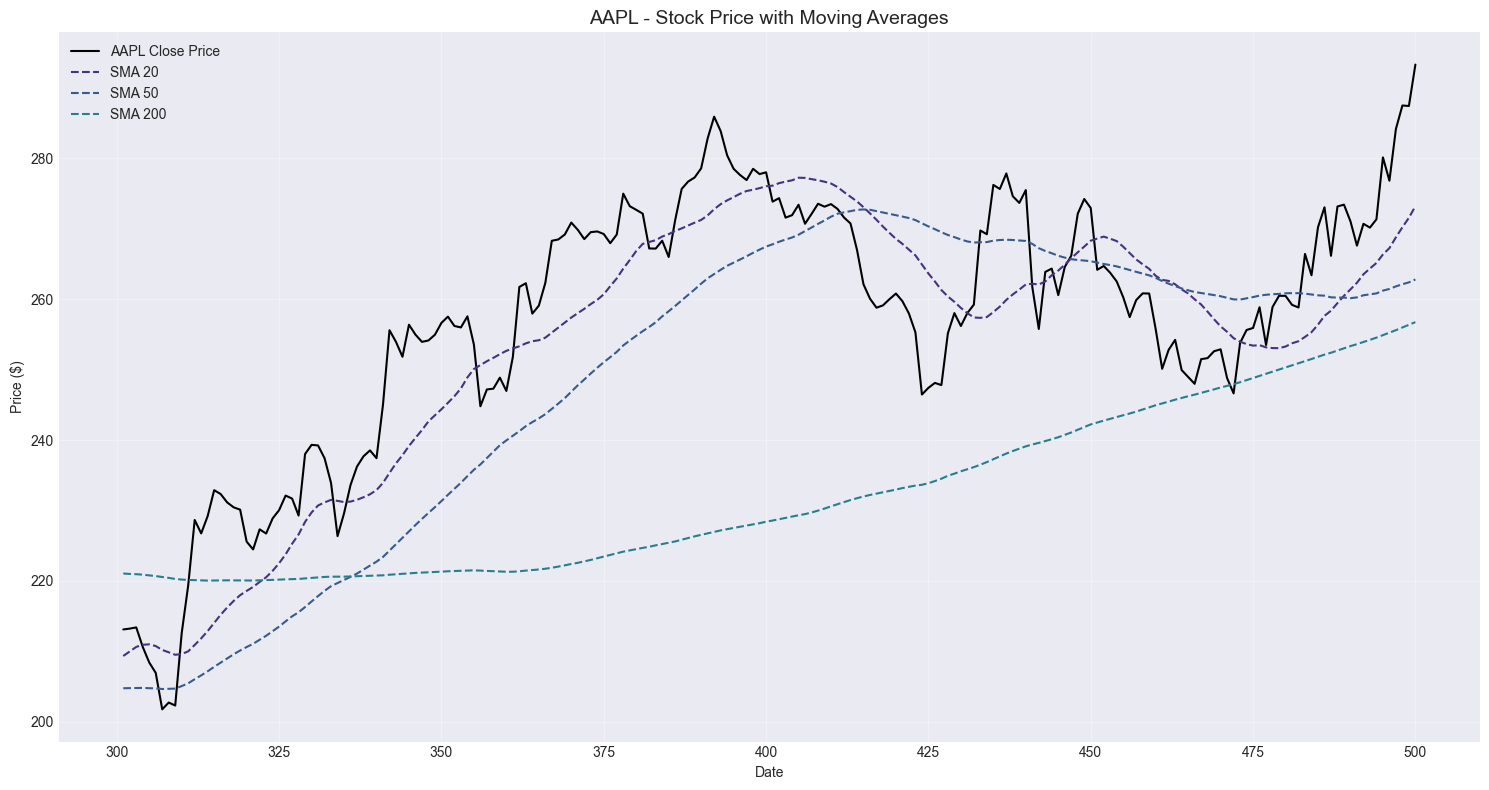

In [34]:
# Plot Price with Moving Averages
if stock_df is not None:
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Plot last 200 days
    plot_df = stock_df.tail(200)
    
    ax.plot(plot_df.index, plot_df[price_col], label=f'{stock_name} Close Price', linewidth=1.5, color='black')
    ax.plot(plot_df.index, plot_df['SMA_20'], label='SMA 20', linewidth=1.5, linestyle='--')
    ax.plot(plot_df.index, plot_df['SMA_50'], label='SMA 50', linewidth=1.5, linestyle='--')
    ax.plot(plot_df.index, plot_df['SMA_200'], label='SMA 200', linewidth=1.5, linestyle='--')
    
    ax.set_title(f'{stock_name} - Stock Price with Moving Averages', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

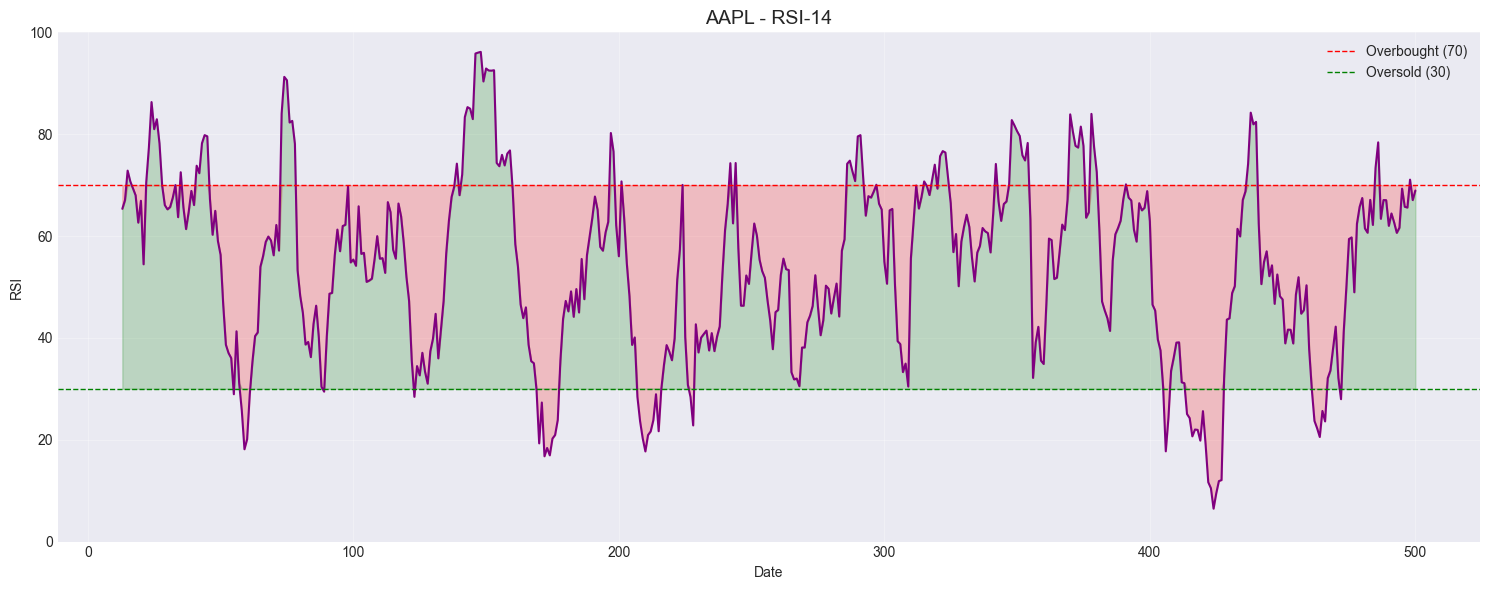

In [35]:
# Plot RSI
if stock_df is not None:
    fig, ax = plt.subplots(figsize=(15, 6))
    
    ax.plot(stock_df.index, stock_df['RSI_14'], color='purple', linewidth=1.5)
    ax.axhline(y=70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
    ax.axhline(y=30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
    ax.fill_between(stock_df.index, 70, stock_df['RSI_14'].clip(upper=70), color='red', alpha=0.2)
    ax.fill_between(stock_df.index, 30, stock_df['RSI_14'].clip(lower=30), color='green', alpha=0.2)
    
    ax.set_title(f'{stock_name} - RSI-14', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('RSI')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [38]:
# Calculate MACD
if stock_df is not None and price_col is not None:
    # Ensure prices are numeric
    prices = pd.to_numeric(stock_df[price_col], errors='coerce')
    
    # Calculate EMAs
    ema_12 = prices.ewm(span=12, adjust=False).mean()
    ema_26 = prices.ewm(span=26, adjust=False).mean()
    
    # MACD line
    stock_df['MACD'] = ema_12 - ema_26
    
    # Signal line (9-day EMA of MACD)
    stock_df['MACD_signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()
    
    # Histogram
    stock_df['MACD_histogram'] = stock_df['MACD'] - stock_df['MACD_signal']
    
    print(" MACD calculated successfully!")
    print(f"\nLatest MACD values:")
    print(stock_df[['MACD', 'MACD_signal', 'MACD_histogram']].tail(5))
else:
    print("Please make sure stock_df and price_col are defined")

 MACD calculated successfully!

Latest MACD values:
         MACD  MACD_signal  MACD_histogram
496  4.559334     3.675739        0.883595
497  5.248893     3.990370        1.258523
498  5.994972     4.391290        1.603682
499  6.505603     4.814153        1.691450
500  7.300592     5.311441        1.989152


In [39]:
# Calculate Bollinger Bands
if stock_df is not None and price_col is not None:
    prices = pd.to_numeric(stock_df[price_col], errors='coerce')
    window = 20
    std_dev = 2
    
    stock_df['BB_middle'] = prices.rolling(window=window).mean()
    bb_std = prices.rolling(window=window).std()
    stock_df['BB_upper'] = stock_df['BB_middle'] + (bb_std * std_dev)
    stock_df['BB_lower'] = stock_df['BB_middle'] - (bb_std * std_dev)
    stock_df['BB_position'] = (stock_df[price_col] - stock_df['BB_lower']) / (stock_df['BB_upper'] - stock_df['BB_lower'])
    
    print(" Bollinger Bands calculated successfully!")
    print(f"\nLatest Bollinger Bands:")
    print(stock_df[['BB_upper', 'BB_middle', 'BB_lower']].tail(3))

 Bollinger Bands calculated successfully!

Latest Bollinger Bands:
       BB_upper   BB_middle    BB_lower
498  286.049819  270.222000  254.394182
499  288.461739  271.569501  254.677262
500  291.858279  273.211501  254.564722


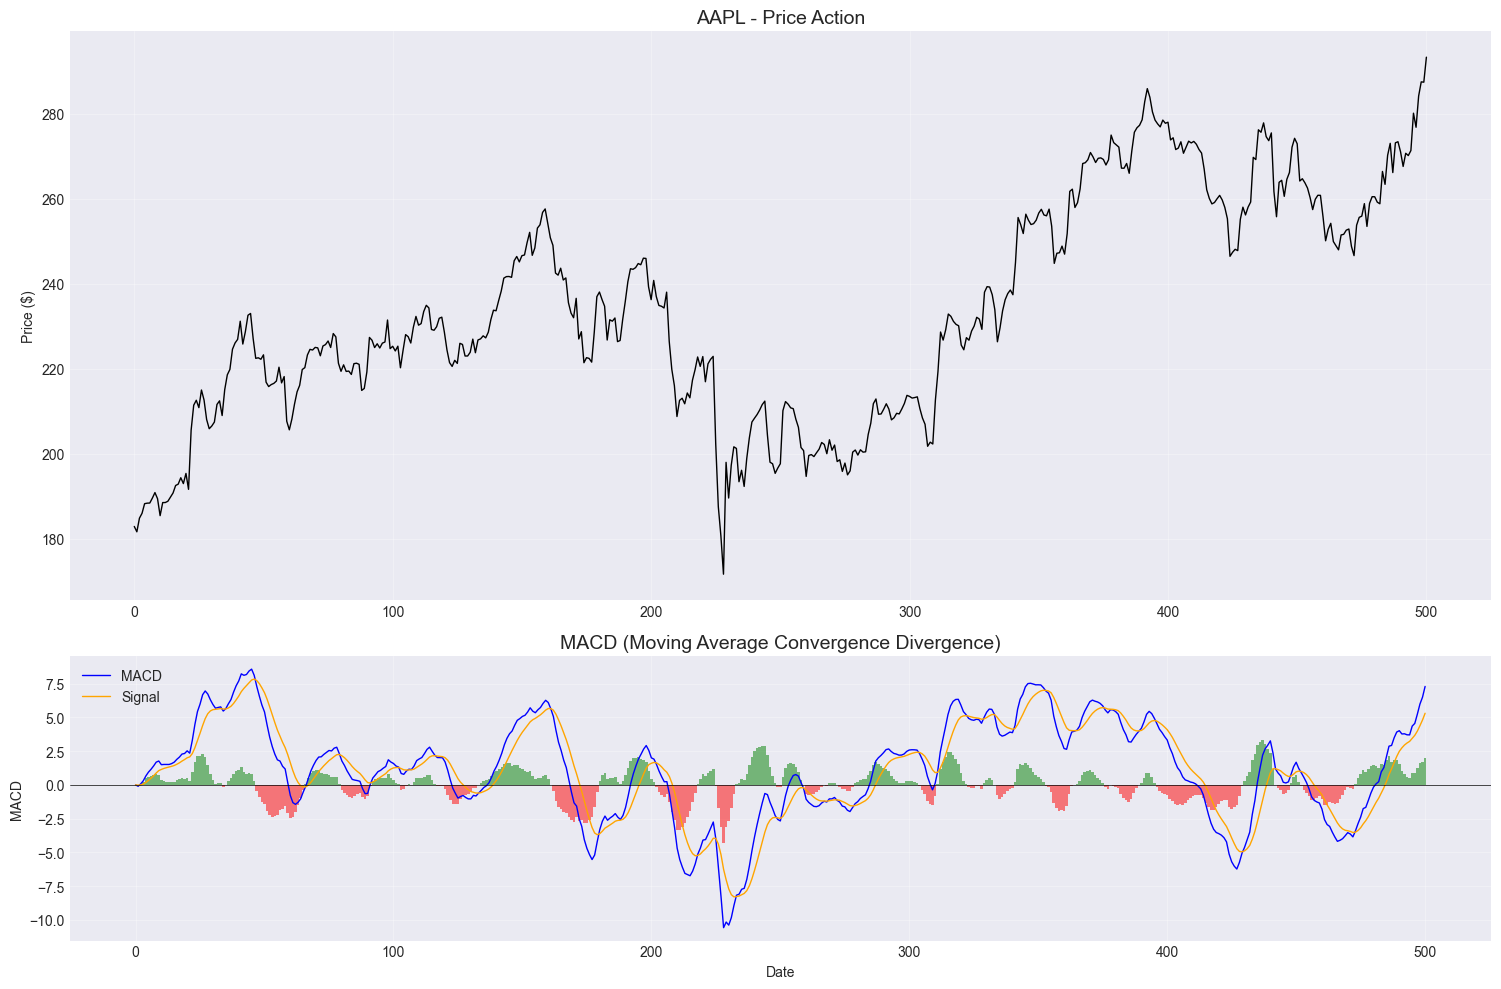

In [40]:
# MACD Chart
if stock_df is not None and 'MACD' in stock_df.columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    # Price chart
    ax1.plot(stock_df.index, stock_df[price_col], color='black', linewidth=1)
    ax1.set_title(f'{stock_name} - Price Action', fontsize=14)
    ax1.set_ylabel('Price ($)')
    ax1.grid(True, alpha=0.3)
    
    # MACD chart
    ax2.plot(stock_df.index, stock_df['MACD'], label='MACD', color='blue', linewidth=1)
    ax2.plot(stock_df.index, stock_df['MACD_signal'], label='Signal', color='orange', linewidth=1)
    
    # Histogram
    colors = ['green' if val >= 0 else 'red' for val in stock_df['MACD_histogram']]
    ax2.bar(stock_df.index, stock_df['MACD_histogram'], color=colors, alpha=0.5, width=1)
    
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_title('MACD (Moving Average Convergence Divergence)', fontsize=14)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('MACD')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Please run Step 1 to calculate MACD first")

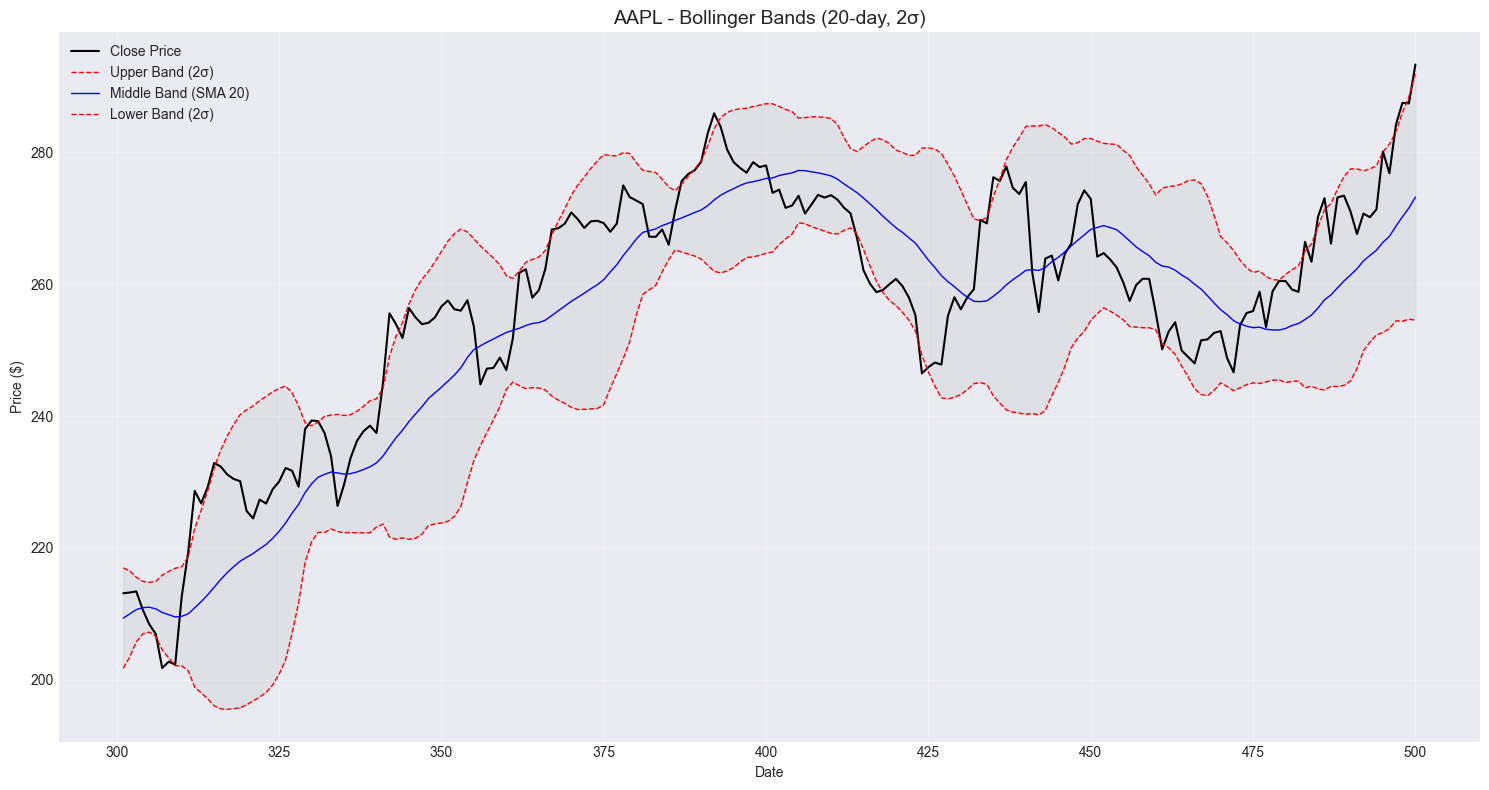

In [41]:
# Bollinger Bands Chart
if stock_df is not None and 'BB_upper' in stock_df.columns:
    fig, ax = plt.subplots(figsize=(15, 8))
    
    plot_df = stock_df.tail(200)
    
    ax.plot(plot_df.index, plot_df[price_col], label='Close Price', linewidth=1.5, color='black')
    ax.plot(plot_df.index, plot_df['BB_upper'], label='Upper Band (2σ)', linewidth=1, color='red', linestyle='--')
    ax.plot(plot_df.index, plot_df['BB_middle'], label='Middle Band (SMA 20)', linewidth=1, color='blue', linestyle='-')
    ax.plot(plot_df.index, plot_df['BB_lower'], label='Lower Band (2σ)', linewidth=1, color='red', linestyle='--')
    
    ax.fill_between(plot_df.index, plot_df['BB_upper'], plot_df['BB_lower'], alpha=0.1, color='gray')
    
    ax.set_title(f'{stock_name} - Bollinger Bands (20-day, 2σ)', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Please run Step 2 to calculate Bollinger Bands first")

In [43]:
# Check the index type
print(f"Index type: {type(stock_df.index)}")
print(f"Last index value: {stock_df.index[-1]}")
print(f"Index sample: {stock_df.index[:5]}")

Index type: <class 'pandas.RangeIndex'>
Last index value: 500
Index sample: RangeIndex(start=0, stop=5, step=1)


In [44]:
# Ensure the index is datetime
if stock_df is not None:
    # Convert index to datetime if it's not already
    if not isinstance(stock_df.index, pd.DatetimeIndex):
        print("Converting index to datetime...")
        stock_df.index = pd.to_datetime(stock_df.index)
    
    # Sort the index
    stock_df = stock_df.sort_index()
    
    print(f" Fixed index type: {type(stock_df.index)}")
    print(f"Date range: {stock_df.index.min()} to {stock_df.index.max()}")
    print(f"Last date: {stock_df.index[-1]}")

Converting index to datetime...
 Fixed index type: <class 'pandas.DatetimeIndex'>
Date range: 1970-01-01 00:00:00 to 1970-01-01 00:00:00.000000500
Last date: 1970-01-01 00:00:00.000000500


In [45]:
# Final Summary - Fixed version
if stock_df is not None:
    latest = stock_df.iloc[-1]
    
    print("="*60)
    print(f"TASK 2 COMPLETE - TECHNICAL INDICATORS SUMMARY")
    print(f"Stock: {stock_name}")
    print("="*60)
    
    # Handle date safely
    last_date = stock_df.index[-1]
    if hasattr(last_date, 'strftime'):
        date_str = last_date.strftime('%Y-%m-%d')
    else:
        date_str = str(last_date)
    
    print(f"\n📅 Date: {date_str}")
    print(f"💰 Price: ${latest[price_col]:.2f}")
    
    print(f"\n📈 MOVING AVERAGES:")
    if 'SMA_20' in stock_df.columns and not pd.isna(latest['SMA_20']):
        print(f"   SMA 20:  ${latest['SMA_20']:.2f} {'▲ Above' if latest[price_col] > latest['SMA_20'] else '▼ Below'}")
        print(f"   SMA 50:  ${latest['SMA_50']:.2f} {'▲ Above' if latest[price_col] > latest['SMA_50'] else '▼ Below'}")
        if 'SMA_200' in stock_df.columns and not pd.isna(latest['SMA_200']):
            print(f"   SMA 200: ${latest['SMA_200']:.2f} {'▲ Above' if latest[price_col] > latest['SMA_200'] else '▼ Below'}")
        
        if latest['SMA_20'] > latest['SMA_50']:
            print(f"   🟢 SIGNAL: GOLDEN CROSS (Bullish)")
        else:
            print(f"   🔴 SIGNAL: DEATH CROSS (Bearish)")
    else:
        print("   Moving averages: Insufficient data")
    
    print(f"\n📉 RSI (14):")
    if 'RSI_14' in stock_df.columns and not pd.isna(latest['RSI_14']):
        print(f"   Value: {latest['RSI_14']:.2f}")
        if latest['RSI_14'] > 70:
            print(f"   🟠 OVERBOUGHT - Consider SELLING")
        elif latest['RSI_14'] < 30:
            print(f"   🟢 OVERSOLD - Consider BUYING")
        else:
            print(f"   ⚪ Neutral Zone")
    else:
        print("   RSI: Calculating... (need more data)")
    
    print(f"\n📊 MACD:")
    if 'MACD' in stock_df.columns and not pd.isna(latest['MACD']):
        macd_diff = latest['MACD'] - latest['MACD_signal']
        print(f"   MACD - Signal: {macd_diff:.4f}")
        if macd_diff > 0:
            print(f"   🟢 BULLISH (Positive Momentum)")
        else:
            print(f"   🔴 BEARISH (Negative Momentum)")
    else:
        print("   MACD: Calculating... (need more data)")
    
    print(f"\n📦 BOLLINGER BANDS:")
    if 'BB_position' in stock_df.columns and not pd.isna(latest['BB_position']):
        bb_position = latest['BB_position']
        print(f"   Position: {bb_position:.2f} (0=lower, 1=upper)")
        if bb_position < 0.2:
            print(f"   🟢 Price near LOWER band - Potential BUY")
        elif bb_position > 0.8:
            print(f"   🟠 Price near UPPER band - Potential SELL")
        else:
            print(f"   ⚪ Trading within normal range")
    else:
        print("   Bollinger Bands: Calculating... (need more data)")
    
    print("\n" + "="*60)
    print(" TASK 2 TECHNICAL INDICATORS READY!")
    print("="*60)

TASK 2 COMPLETE - TECHNICAL INDICATORS SUMMARY
Stock: AAPL

📅 Date: 1970-01-01
💰 Price: $293.32

📈 MOVING AVERAGES:
   SMA 20:  $273.21 ▲ Above
   SMA 50:  $262.80 ▲ Above
   SMA 200: $256.75 ▲ Above
   🟢 SIGNAL: GOLDEN CROSS (Bullish)

📉 RSI (14):
   Value: 68.94
   ⚪ Neutral Zone

📊 MACD:
   MACD - Signal: 1.9892
   🟢 BULLISH (Positive Momentum)

📦 BOLLINGER BANDS:
   Position: 1.04 (0=lower, 1=upper)
   🟠 Price near UPPER band - Potential SELL

 TASK 2 TECHNICAL INDICATORS READY!


In [47]:
output_path = r'C:\Users\HP\news-sentiment-analysis\data\stock_with_indicators.csv'
stock_df.to_csv(output_path)
print(f" Technical indicators saved to: {output_path}")
print(f"   Shape: {stock_df.shape}")
print(f"   Date range in file: {stock_df.index.min()} to {stock_df.index.max()}")

 Technical indicators saved to: C:\Users\HP\news-sentiment-analysis\data\stock_with_indicators.csv
   Shape: (501, 17)
   Date range in file: 1970-01-01 00:00:00 to 1970-01-01 00:00:00.000000500


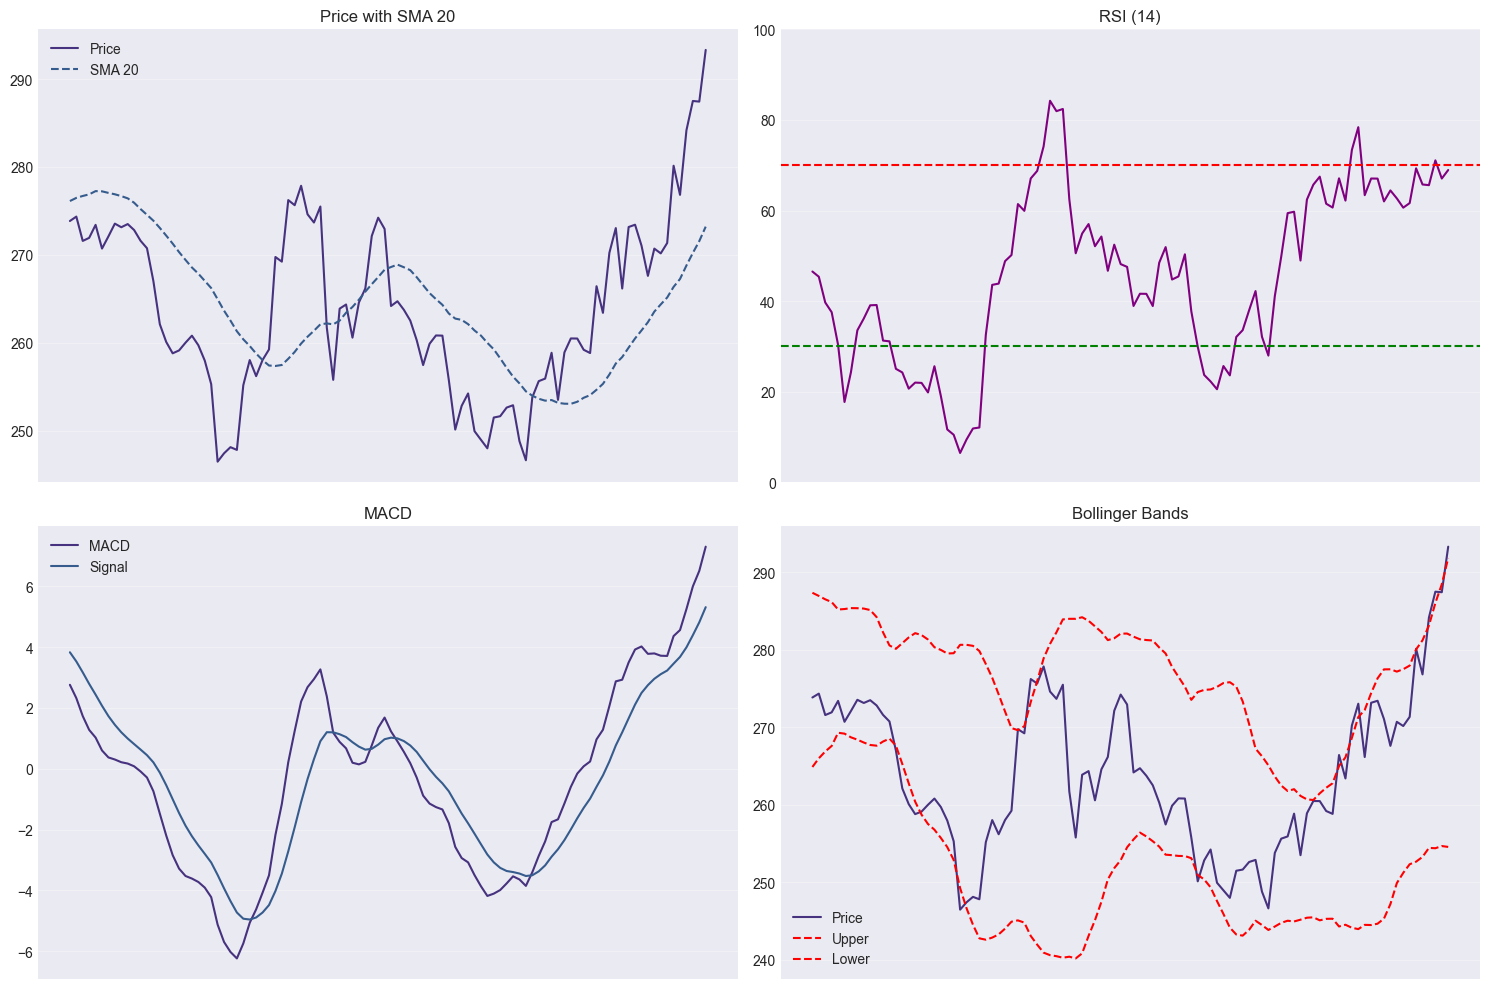

 All plots generated successfully!


In [49]:
# Quick plot to verify everything is working
if stock_df is not None and len(stock_df) > 20:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Price with SMA
    axes[0,0].plot(stock_df.index[-100:], stock_df[price_col].iloc[-100:], label='Price')
    if 'SMA_20' in stock_df.columns:
        axes[0,0].plot(stock_df.index[-100:], stock_df['SMA_20'].iloc[-100:], label='SMA 20', linestyle='--')
    axes[0,0].set_title('Price with SMA 20')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: RSI
    if 'RSI_14' in stock_df.columns:
        axes[0,1].plot(stock_df.index[-100:], stock_df['RSI_14'].iloc[-100:], color='purple')
        axes[0,1].axhline(y=70, color='r', linestyle='--')
        axes[0,1].axhline(y=30, color='g', linestyle='--')
        axes[0,1].set_title('RSI (14)')
        axes[0,1].set_ylim(0, 100)
        axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: MACD
    if 'MACD' in stock_df.columns:
        axes[1,0].plot(stock_df.index[-100:], stock_df['MACD'].iloc[-100:], label='MACD')
        axes[1,0].plot(stock_df.index[-100:], stock_df['MACD_signal'].iloc[-100:], label='Signal')
        axes[1,0].set_title('MACD')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
    
    # Plot 4: Bollinger Bands
    if 'BB_upper' in stock_df.columns:
        axes[1,1].plot(stock_df.index[-100:], stock_df[price_col].iloc[-100:], label='Price')
        axes[1,1].plot(stock_df.index[-100:], stock_df['BB_upper'].iloc[-100:], 'r--', label='Upper')
        axes[1,1].plot(stock_df.index[-100:], stock_df['BB_lower'].iloc[-100:], 'r--', label='Lower')
        axes[1,1].set_title('Bollinger Bands')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print(" All plots generated successfully!")